# MDR-TS v20.8 — Spatial Generalisation Evaluation

**Goal**: Train the v20.7 3-regime XGBoost ensemble on *all 5* Washington State stations from `derived_8.0`, then evaluate zero-shot on **15 never-seen stations** spanning Oregon, Idaho, and Montana.

**What makes this different from v20.7**: v20.7 did LOSO within the 5 WA stations. v20.8 asks whether the model generalises across state lines, climate gradients, and network types (SNOTEL, USCRN, SCAN, COSMOS, PBO-H2O).

## Pipeline overview
```
1. Load derived_8.0  →  train on ALL 5 WA stations
2. For each eval station:
   a. Download soil-moisture ground truth (NRCS AWDB / NOAA)
   b. Fetch satellite features via GEE (SMAP, S1, MODIS-LST, S2)
   c. Fetch precipitation via Open-Meteo
   d. Compute static terrain+soil features via GEE (SRTM / OpenLandMap)
   e. Engineer all v20.7 derived features
3. Predict & evaluate
```

**Notes**:
- `EVAL_START` / `EVAL_END` below define the evaluation window (default: 7-day window)
- Feature lookback begins 60 days before `EVAL_END` to satisfy all 30-day rolling windows
- COSMOS (Metolius) and PBO-H2O (HORSHEAVEN, SHANIKO) require manual download — see Section 5c

## 0. Imports

In [1]:
import os, sys, json, warnings, random
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from xgboost import XGBRegressor, XGBClassifier
import joblib

warnings.filterwarnings('ignore')

# ── project root on path ───────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(os.path.abspath('.'))
PROJECT_ROOT = NOTEBOOK_DIR.parents[3]   # …/MDR-Project
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)

Project root: c:\Users\Daniel Kirov-Tomilov\Desktop\2025_26_SU\clones\MDR-Project


## 1. Config

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)

VERSION    = 'v20'
SUBVERSION = 'v20.8'

DATA_ROOT   = PROJECT_ROOT / 'Temporal' / 'Pipeline' / 'data'
SPLIT_ROOT  = DATA_ROOT / 'splits'
OUTPUT_ROOT = PROJECT_ROOT / 'Models' / 'Temporal' / VERSION / SUBVERSION
V205_ROOT   = PROJECT_ROOT / 'Models' / 'Temporal' / VERSION / 'v20.5'

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SPLIT = 'derived_8.0'
GEE_PROJECT = 'mdr-research'

# ── Evaluation window (7-day eval, 60-day feature lookback) ───────────────────
# Adjust EVAL_END to the latest date for which all satellite products are available.
# SMAP latency ~3 days, S1/S2 ~1 day, MODIS LST ~1-2 days.
EVAL_END   = '2025-11-14'   # last day of eval window (inclusive)
EVAL_START = '2025-11-08'   # first day of eval window (7 days)
FETCH_START = (datetime.strptime(EVAL_END, '%Y-%m-%d') - timedelta(days=60)).strftime('%Y-%m-%d')

print(f'Feature fetch window : {FETCH_START}  →  {EVAL_END}')
print(f'Evaluation window    : {EVAL_START}  →  {EVAL_END}')
print(f'Output               : {OUTPUT_ROOT}')

Feature fetch window : 2025-09-15  →  2025-11-14
Evaluation window    : 2025-11-08  →  2025-11-14
Output               : c:\Users\Daniel Kirov-Tomilov\Desktop\2025_26_SU\clones\MDR-Project\Models\Temporal\v20\v20.8


## 2. Feature column definitions  *(identical to v20.7)*

In [3]:
TARGET_COL     = 'soil_moisture_5cm'
KEEP_META_COLS = ['station_id', 'date', 'longitude', 'latitude']

FEATURE_COLS_BASE = [
    'SMAP_sm_pm_interp_ema02', 'SMAP_sm_interp_grad7', 'SMAP_ampm_diff_interp',
    'G_API', 'G_rain_sum_3d', 'G_rain_sum_7d',
    'V_ema_G_API_kobs7', 'V_ema_G_API_kobs14', 'V_ema_G_API_kobs30',
    'V_rollmean_G_API_kobs7', 'V_rollmean_G_API_kobs14',
    'A_d_E_SAR_diff_kobs14',
    'V_ema_LST_modis_kobs7', 'A_d_LST_modis_kobs14', 'V_rollmin_LST_modis_kobs30',
    'V_rollmean_s2_b11_kobs7',
    'year_frac', 'sin_year', 'cos_year',
    'API_x_year', 'SMAP_x_year',
    'slope', 'elev',
    'K_slope_sin', 'K_slope_cos', 'K_aspect_cos',
    'J_clay_wfrac_b0', 'J_sand_wfrac_b0',
]

FEATURE_COLS_DRY = [
    'SMAP_sm_pm_interp_ema02', 'SMAP_sm_interp_grad7', 'SMAP_sm_interp_diff1',
    'A_d_SMAP_sm_interp_kobs14',
    'V_ema_LST_modis_kobs7', 'V_rollmin_LST_modis_kobs30', 'A_d_LST_modis_kobs14',
    'slope', 'elev',
    'K_slope_sin', 'K_slope_cos', 'K_aspect_cos',
    'J_clay_wfrac_b0', 'J_sand_wfrac_b0',
    'G_API', 'V_ema_G_API_kobs14', 'C_lag_G_API_kobs1',
    'V_rollmean_s2_b11_kobs7',
    'year_frac', 'sin_year', 'cos_year',
]

FEATURE_COLS_WET = [
    'SMAP_sm_interp_diff1', 'SMAP_sm_interp_rollstd7', 'SMAP_sm_interp_rollrange7', 'SMAP_sm_interp_pctchg',
    'A_d_SMAP_sm_interp_kobs7', 'A_grad_SMAP_sm_interp_kobs7', 'A_pct_SMAP_sm_interp',
    'G_API', 'G_rain_sum_3d', 'G_rain_sum_7d',
    'V_rollstd_G_API_kobs7', 'V_rollcv_G_API_kobs7', 'A_d_G_API_kobs7',
    'A_d_E_SAR_diff_kobs1', 'A_d_E_SAR_diff_kobs7',
    'A_grad_E_SAR_diff_kobs7', 'A_grad_E_SAR_ratio_kobs7',
    'V_rollstd_E_SAR_diff_kobs7', 'V_rollstd_E_SAR_ratio_kobs7',
    'V_rollstd_F_NDMI_kobs7', 'A_d_F_NDMI_kobs7',
    'year_frac', 'sin_year', 'cos_year',
    'slope', 'elev',
]

ALL_FEATS = sorted(set(FEATURE_COLS_BASE + FEATURE_COLS_DRY + FEATURE_COLS_WET))
print(f'Feature sets — BASE:{len(FEATURE_COLS_BASE)}  DRY:{len(FEATURE_COLS_DRY)}  WET:{len(FEATURE_COLS_WET)}  UNION:{len(ALL_FEATS)}')

Feature sets — BASE:28  DRY:21  WET:26  UNION:48


## 3. Model hyperparameters & helpers  *(identical to v20.7)*

In [4]:
XGB_PARAMS_DRY = dict(
    objective='reg:absoluteerror', random_state=SEED, n_jobs=-1,
    subsample=0.9, colsample_bytree=0.8, max_depth=8, min_child_weight=2,
    n_estimators=5500, learning_rate=0.04, reg_lambda=1.5, reg_alpha=0.03, gamma=0.0,
)
XGB_PARAMS_TRANSITION = dict(
    objective='reg:absoluteerror', random_state=SEED, n_jobs=-1,
    max_depth=7, min_child_weight=5, subsample=0.9, colsample_bytree=0.85,
    n_estimators=8000, learning_rate=0.03, reg_lambda=3.0, reg_alpha=0.05,
)
XGB_PARAMS_WET = dict(
    objective='reg:squarederror', random_state=SEED, n_jobs=-1,
    max_depth=10, min_child_weight=1, subsample=1.0, colsample_bytree=0.9,
    n_estimators=6000, learning_rate=0.03, reg_lambda=0.3, reg_alpha=0.0,
)

T1, T2 = 0.20, 0.313
STABLE_THRESH = 0.60

def label_regime(y, t1=T1, t2=T2):
    y = np.asarray(y).ravel()
    out = np.zeros(len(y), dtype=int)
    out[(y > t1) & (y <= t2)] = 1
    out[y > t2] = 2
    return out

def get_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()
    err = y_true - y_pred
    return dict(n=int(len(y_true)), r2=float(r2_score(y_true, y_pred)),
                mae=float(mean_absolute_error(y_true, y_pred)),
                rmse=float(root_mean_squared_error(y_true, y_pred)),
                ubrmse=float(np.std(err)), bias=float(np.mean(err)))

def make_final_pred(base_pred, pred_trans, pred_wet, p_stable, t1=T1, t2=T2, thresh=STABLE_THRESH):
    mask_dry   = base_pred <= t1
    mask_trans = (base_pred > t1) & (base_pred <= t2)
    mask_wet   = base_pred > t2
    is_stable  = p_stable >= thresh
    pred = np.zeros_like(base_pred, dtype=float)
    pred[mask_dry]                  = base_pred[mask_dry]
    pred[mask_wet]                  = pred_wet[mask_wet]
    pred[mask_trans &  is_stable]   = base_pred[mask_trans & is_stable]
    pred[mask_trans & ~is_stable]   = pred_trans[mask_trans & ~is_stable]
    return pred

print('Helpers defined | T1=%.3f  T2=%.3f' % (T1, T2))

Helpers defined | T1=0.200  T2=0.313


## 4. Station metadata

In [5]:
# Raw metadata from spatial_eval_stations.csv
# clay / sand / silt are in g/kg (sum ≈ 1000) — used only for reference;
# J_clay_wfrac_b0 and J_sand_wfrac_b0 come from OpenLandMap via GEE (Section 6).

STATION_META = [
    # ── WA (in derived_8.0 — kept for reference, NOT used as eval targets) ──
    dict(station_id='Darrington',            lat=48.5405, lon=-121.446, elev=124,  state='WA', network='USCRN',   split='WA_train'),
    dict(station_id='Quinault',              lat=47.5139, lon=-123.812, elev=87,   state='WA', network='USCRN',   split='WA_train'),
    dict(station_id='Spokane',               lat=47.4174, lon=-117.526, elev=691,  state='WA', network='USCRN',   split='WA_train'),
    dict(station_id='SourdoughGulch',        lat=46.2371, lon=-117.394, elev=1207, state='WA', network='SNOTEL',  split='WA_train'),
    dict(station_id='Touchet',               lat=46.1187, lon=-117.851, elev=1682, state='WA', network='SNOTEL',  split='WA_train'),
    # ── Oregon ────────────────────────────────────────────────────────────────
    dict(station_id='Miller_Woods',          lat=45.248,  lon=-123.276, elev=128,  state='OR', network='SNOTEL',  split='eval'),
    dict(station_id='Blazed_Alder',          lat=45.429,  lon=-121.856, elev=1116, state='OR', network='SNOTEL',  split='eval'),
    dict(station_id='Clackamas_Lake',        lat=45.097,  lon=-121.754, elev=1036, state='OR', network='SNOTEL',  split='eval'),
    dict(station_id='Metolius',              lat=44.452,  lon=-121.557, elev=1253, state='OR', network='COSMOS',  split='eval'),
    dict(station_id='HORSHEAVEN',            lat=45.911,  lon=-120.005, elev=262,  state='OR', network='PBO-H2O', split='eval'),
    dict(station_id='SHANIKO',               lat=44.923,  lon=-120.946, elev=965,  state='OR', network='PBO-H2O', split='eval'),
    dict(station_id='Rock_Springs',          lat=44.009,  lon=-118.838, elev=1612, state='OR', network='SNOTEL',  split='eval'),
    dict(station_id='Corvallis_10_SSW',      lat=44.419,  lon=-123.326, elev=95,   state='OR', network='USCRN',   split='eval'),
    dict(station_id='Bourne',                lat=44.831,  lon=-118.188, elev=1783, state='OR', network='SNOTEL',  split='eval'),
    # ── Idaho ─────────────────────────────────────────────────────────────────
    dict(station_id='Shanghi_Summit',        lat=46.566,  lon=-115.742, elev=1399, state='ID', network='SNOTEL',  split='eval'),
    dict(station_id='Moscow_Mountain',       lat=46.805,  lon=-116.854, elev=1433, state='ID', network='SNOTEL',  split='eval'),
    dict(station_id='Mica_Creek',            lat=47.15,   lon=-116.266, elev=1366, state='ID', network='SNOTEL',  split='eval'),
    dict(station_id='Long_Valley',           lat=44.788,  lon=-116.089, elev=1490, state='ID', network='SNOTEL',  split='eval'),
    # ── Montana ───────────────────────────────────────────────────────────────
    dict(station_id='Table_Mountain',        lat=45.803,  lon=-111.587, elev=1364, state='MT', network='SCAN',    split='eval'),
    dict(station_id='Violett',               lat=48.436,  lon=-111.184, elev=983,  state='MT', network='SCAN',    split='eval'),
    # ── USCRN eval stations (confirmed SM data, 60+ days) ────────────────────
    dict(station_id='OR_John_Day_35_WNW',   lat=44.56,  lon=-119.65,  elev=710,  state='OR', network='USCRN', split='eval'),
    dict(station_id='OR_Riley_10_WSW',       lat=43.47,  lon=-119.69,  elev=1396, state='OR', network='USCRN', split='eval'),
    dict(station_id='ID_Arco_17_SW',         lat=43.46,  lon=-113.56,  elev=1790, state='ID', network='USCRN', split='eval'),
    dict(station_id='ID_Murphy_10_W',        lat=43.20,  lon=-116.75,  elev=1216, state='ID', network='USCRN', split='eval'),
    dict(station_id='MT_Dillon_18_WSW',      lat=45.16,  lon=-113.01,  elev=1792, state='MT', network='USCRN', split='eval'),
    dict(station_id='MT_Lewistown_42_WSW',   lat=46.88,  lon=-110.29,  elev=1550, state='MT', network='USCRN', split='eval'),
    dict(station_id='MT_Wolf_Point_29_ENE',  lat=48.31,  lon=-105.10,  elev=631,  state='MT', network='USCRN', split='eval'),
    dict(station_id='CA_Bodega_6_WSW',       lat=38.32,  lon=-123.07,  elev=14,   state='CA', network='USCRN', split='eval'),
    dict(station_id='CA_Redding_12_WNW',     lat=40.65,  lon=-122.61,  elev=432,  state='CA', network='USCRN', split='eval'),
    dict(station_id='NV_Baker_5_W',          lat=39.01,  lon=-114.21,  elev=2016, state='NV', network='USCRN', split='eval'),
    dict(station_id='NV_Denio_52_WSW',       lat=41.85,  lon=-119.64,  elev=1988, state='NV', network='USCRN', split='eval'),
    dict(station_id='WY_Moose_1_NNE',        lat=43.66,  lon=-110.71,  elev=1965, state='WY', network='USCRN', split='eval'),
    dict(station_id='WY_Lander_11_SSE',      lat=42.68,  lon=-108.67,  elev=1717, state='WY', network='USCRN', split='eval'),
    dict(station_id='WY_Sundance_8_NNW',     lat=44.52,  lon=-104.44,  elev=1754, state='WY', network='USCRN', split='eval'),
    dict(station_id='CO_Boulder_14_W',       lat=40.04,  lon=-105.54,  elev=2972, state='CO', network='USCRN', split='eval'),
]

meta_df = pd.DataFrame(STATION_META)
eval_meta = meta_df[meta_df['split'] == 'eval'].reset_index(drop=True)

print(f'Total stations: {len(meta_df)}  |  Eval stations: {len(eval_meta)}')
print(eval_meta[['station_id','state','network']].to_string(index=False))

Total stations: 35  |  Eval stations: 30
          station_id state network
        Miller_Woods    OR  SNOTEL
        Blazed_Alder    OR  SNOTEL
      Clackamas_Lake    OR  SNOTEL
            Metolius    OR  COSMOS
          HORSHEAVEN    OR PBO-H2O
             SHANIKO    OR PBO-H2O
        Rock_Springs    OR  SNOTEL
    Corvallis_10_SSW    OR   USCRN
              Bourne    OR  SNOTEL
      Shanghi_Summit    ID  SNOTEL
     Moscow_Mountain    ID  SNOTEL
          Mica_Creek    ID  SNOTEL
         Long_Valley    ID  SNOTEL
      Table_Mountain    MT    SCAN
             Violett    MT    SCAN
  OR_John_Day_35_WNW    OR   USCRN
     OR_Riley_10_WSW    OR   USCRN
       ID_Arco_17_SW    ID   USCRN
      ID_Murphy_10_W    ID   USCRN
    MT_Dillon_18_WSW    MT   USCRN
 MT_Lewistown_42_WSW    MT   USCRN
MT_Wolf_Point_29_ENE    MT   USCRN
     CA_Bodega_6_WSW    CA   USCRN
   CA_Redding_12_WNW    CA   USCRN
        NV_Baker_5_W    NV   USCRN
     NV_Denio_52_WSW    NV   USCRN
      WY_Moose

## 5. Load WA training data  *(all 5 stations from derived_8.0)*

In [6]:
train_raw = pd.read_csv(SPLIT_ROOT / SPLIT / 'train.csv')
val_raw   = pd.read_csv(SPLIT_ROOT / SPLIT / 'val.csv')
test_raw  = pd.read_csv(SPLIT_ROOT / SPLIT / 'test.csv')

# Use train+val for training (identical to v20.7 approach)
trainval_df = pd.concat([train_raw, val_raw], ignore_index=True)

print(f'trainval rows: {len(trainval_df):,}   stations: {sorted(trainval_df["station_id"].unique())}')

# Verify all v20.7 features are present
missing = [f for f in ALL_FEATS if f not in trainval_df.columns]
print('Missing features:', missing if missing else 'NONE — all present ✓')

trainval rows: 9,588   stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
Missing features: NONE — all present ✓


## 6. Train v20.7 model on all WA data

In [7]:
X_tv_base = trainval_df[FEATURE_COLS_BASE]
X_tv_wet  = trainval_df[FEATURE_COLS_WET]
y_tv      = trainval_df[TARGET_COL].values

reg_tv        = label_regime(y_tv)
mask_trans_tv = reg_tv == 1
mask_wet_tv   = reg_tv == 2

print(f'Regime split — dry:{(reg_tv==0).sum():,}  trans:{mask_trans_tv.sum():,}  wet:{mask_wet_tv.sum():,}')

# [1/3] Base / anchor model
print('[1/3] Training base model...')
xgb_base = XGBRegressor(**XGB_PARAMS_DRY)
xgb_base.fit(X_tv_base, y_tv, verbose=0)
pred_base_tv = xgb_base.predict(X_tv_base)

# [2/3] Transition specialist
X_tv_aug = np.column_stack([X_tv_wet, pred_base_tv])
print('[2/3] Training transition model...')
xgb_trans = XGBRegressor(**XGB_PARAMS_TRANSITION)
xgb_trans.fit(X_tv_aug[mask_trans_tv], y_tv[mask_trans_tv], verbose=0)

# [3/3] Wet specialist
print('[3/3] Training wet model...')
xgb_wet = XGBRegressor(**XGB_PARAMS_WET)
xgb_wet.fit(X_tv_aug[mask_wet_tv], y_tv[mask_wet_tv], verbose=0)

# Try loading regime classifier from v20.5
MODEL_PATH   = V205_ROOT / 'regime_classifier_xgb.json'
IMPUTER_PATH = V205_ROOT / 'stable_classifier_imputer.pkl'
COLS_PATH    = V205_ROOT / 'stable_classifier_cols.pkl'
USE_CLF = all(p.exists() for p in [MODEL_PATH, IMPUTER_PATH, COLS_PATH])
if USE_CLF:
    clf     = XGBClassifier(); clf.load_model(str(MODEL_PATH))
    imputer = joblib.load(str(IMPUTER_PATH))
    CLF_COLS = joblib.load(str(COLS_PATH))
    print(f'Regime classifier loaded — {len(CLF_COLS)} features')
else:
    clf = imputer = CLF_COLS = None
    print('Classifier not found — using oracle fallback (p_stable=0)')

print('\nTraining complete.')

Regime split — dry:4,280  trans:3,885  wet:1,423
[1/3] Training base model...
[2/3] Training transition model...
[3/3] Training wet model...
Classifier not found — using oracle fallback (p_stable=0)

Training complete.


## 7. Ground-truth download helpers

### 7a. NRCS AWDB — SNOTEL & SCAN
Uses the public AWDB REST API v1.  No authentication required.

**Element**: `SMS` (Soil Moisture — 2-inch / 5 cm depth).  
SNOTEL Hydraprobe values are volumetric (m³/m³ × 100 → ÷ 100 = m³/m³).  
If `SMS` is unavailable, try element `SMAV` (adjusted).

In [8]:
AWDB_BASE = 'https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1'

def awdb_find_station(station_name: str, state: str, network: str) -> str | None:
    """
    Search NRCS AWDB for a station and return its triplet string  '1234:OR:SNOTEL'.
    Fuzzy match on name — returns the first result.
    """
    url = f'{AWDB_BASE}/stations'
    params = dict(
        stationNames=station_name.replace('_', ' '),
        stateCds=state,
        networkCds=network,
        returnObjects='true',
    )
    try:
        resp = requests.get(url, params=params, verify=False, timeout=30)
        resp.raise_for_status()
        data = resp.json()
    except Exception as e:
        print(f'  AWDB unavailable ({type(e).__name__}): {e}')
        return None
    if not data:
        return None
    # data is a list of station objects; take best match by name similarity
    name_clean = station_name.lower().replace('_', ' ')
    best, best_score = None, -1
    for s in data:
        sname = s.get('name', '').lower()
        score = sum(w in sname for w in name_clean.split())
        if score > best_score:
            best, best_score = s, score
    if best is None:
        return None
    return best.get('stationTriplet')   # e.g. '539:OR:SNOTEL'


def awdb_get_soil_moisture(triplet: str, start: str, end: str,
                           depth_in: int = -2) -> pd.DataFrame:
    """
    Fetch daily SMS (soil moisture) from AWDB for a station triplet.
    Returns DataFrame with columns [date, soil_moisture_5cm].
    depth_in  — depth in inches (negative = below surface): -2 = 2 in = ~5 cm.
    """
    url = f'{AWDB_BASE}/data'
    # Try SMS first, fall back to SMAV
    for element in ['SMS', 'SMAV']:
        params = dict(
            stationTriplets=triplet,
            elements=element,
            beginDate=start,
            endDate=end,
            duration='D',
            getFlags='false',
        )
        try:
            resp = requests.get(url, params=params, verify=False, timeout=60)
            resp.raise_for_status()
        except Exception:
            continue
        data = resp.json()
        if not data:
            continue
        # Flatten element-level response
        rows = []
        for station_data in data:
            for elem_data in station_data.get('data', []):
                depth = elem_data.get('depth', None)
                if depth is not None and int(depth) != depth_in:
                    continue     # wrong depth
                begin = elem_data.get('beginDate', start)
                values = elem_data.get('values', [])
                dates  = pd.date_range(begin, periods=len(values), freq='D')
                for d, v in zip(dates, values):
                    if v is not None:
                        rows.append({'date': d.strftime('%Y-%m-%d'), 'soil_moisture_5cm': float(v)})
        if rows:
            df = pd.DataFrame(rows).drop_duplicates('date').sort_values('date').reset_index(drop=True)
            # Convert % → m³/m³ if values look like percent (> 1.0)
            if df['soil_moisture_5cm'].median() > 1.0:
                df['soil_moisture_5cm'] /= 100.0
            # Mask unrealistic values
            df.loc[~df['soil_moisture_5cm'].between(0.01, 1.0), 'soil_moisture_5cm'] = np.nan
            return df
    return pd.DataFrame(columns=['date', 'soil_moisture_5cm'])


print('NRCS AWDB helpers ready')

NRCS AWDB helpers ready


### 7b. NOAA USCRN — Corvallis 10 SSW

In [9]:
# USCRN daily files: CRND0103-{YEAR}-{STATIONCODE}.txt
# Station codes from: https://www.ncei.noaa.gov/pub/data/uscrn/products/daily01/
USCRN_BASE = 'https://www.ncei.noaa.gov/pub/data/uscrn/products/daily01'

# Known USCRN station codes (from existing pipeline config)
USCRN_STATION_CODES = {
    'Darrington':       'WA_Darrington_21_NNE',
    'Quinault':         'WA_Quinault_4_NE',
    'Spokane':          'WA_Spokane_17_SSW',
    'Corvallis_10_SSW': 'OR_Corvallis_10_SSW',
}

USCRN_COLS = [
    'WBANNO', 'LST_DATE', 'CRX_VN', 'LONGITUDE', 'LATITUDE',
    'T_DAILY_MAX', 'T_DAILY_MIN', 'T_DAILY_MEAN', 'T_DAILY_AVG',
    'P_DAILY_CALC', 'SOLARAD_DAILY', 'SUR_TEMP_DAILY_TYPE',
    'SUR_TEMP_DAILY_MAX', 'SUR_TEMP_DAILY_MIN', 'SUR_TEMP_DAILY_AVG',
    'RH_DAILY_MAX', 'RH_DAILY_MIN', 'RH_DAILY_AVG',
    'SOIL_MOISTURE_5_DAILY', 'SOIL_MOISTURE_10_DAILY',
    'SOIL_MOISTURE_20_DAILY', 'SOIL_MOISTURE_50_DAILY', 'SOIL_MOISTURE_100_DAILY',
    'SOIL_TEMP_5_DAILY', 'SOIL_TEMP_10_DAILY',
    'SOIL_TEMP_20_DAILY', 'SOIL_TEMP_50_DAILY', 'SOIL_TEMP_100_DAILY',
]
USCRN_NA = [-9999.0, -99.0, -999.0]


def uscrn_get_soil_moisture(station_code: str, start: str, end: str) -> pd.DataFrame:
    """Download USCRN daily soil moisture at 5 cm."""
    start_dt, end_dt = datetime.strptime(start, '%Y-%m-%d'), datetime.strptime(end, '%Y-%m-%d')
    years = range(start_dt.year, end_dt.year + 1)
    frames = []
    for yr in years:
        url = f'{USCRN_BASE}/{yr}/CRND0103-{yr}-{station_code}.txt'
        resp = requests.get(url, timeout=30)
        if resp.status_code != 200:
            print(f'  WARNING: {url} → {resp.status_code}')
            continue
        from io import StringIO
        df = pd.read_csv(StringIO(resp.text), sep=r'\s+', header=None,
                         names=USCRN_COLS, na_values=USCRN_NA)
        frames.append(df)
    if not frames:
        return pd.DataFrame(columns=['date', 'soil_moisture_5cm'])
    out = pd.concat(frames, ignore_index=True)
    out['date'] = pd.to_datetime(out['LST_DATE'].astype(str), format='%Y%m%d').dt.strftime('%Y-%m-%d')
    out = out.rename(columns={'SOIL_MOISTURE_5_DAILY': 'soil_moisture_5cm'})
    out = out[['date', 'soil_moisture_5cm']].copy()
    out = out[(out['date'] >= start) & (out['date'] <= end)]
    out = out.dropna(subset=['soil_moisture_5cm']).sort_values('date').reset_index(drop=True)
    return out


print('USCRN helper ready')

USCRN helper ready


### 7c. COSMOS & PBO-H2O — manual download notes

| Station | Network | Data source | Notes |
|---------|---------|-------------|-------|
| Metolius | COSMOS | [COSMOS-USA portal](https://cosmos.arizona.edu/soil-moisture/data) | Search for site "Metolius" → download level-4 daily CSV |
| HORSHEAVEN | PBO-H2O | [UNAVCO PBO H2O](http://geodesy.unr.edu/GNSS_TimeSeries/pboh2o/) | GPS reflectometry SM — site P060 (approx) |
| SHANIKO | PBO-H2O | Same as above | Site P629 (approx) |

Place downloaded CSVs (two columns: `date` YYYY-MM-DD, `soil_moisture_5cm` m³/m³) in:
`Models/Temporal/v20/v20.8/manual_sm/{station_id}.csv`

## 8. Open-Meteo precipitation helper

In [10]:
OPENMETEO_URL = 'https://archive-api.open-meteo.com/v1/archive'

def fetch_precipitation(lat: float, lon: float, start: str, end: str) -> pd.DataFrame:
    """
    Fetch daily precipitation from Open-Meteo historical archive.
    Returns DataFrame with columns [date, precip_mm].
    """
    params = dict(
        latitude=lat, longitude=lon,
        start_date=start, end_date=end,
        daily='precipitation_sum',
        timezone='auto',
    )
    resp = requests.get(OPENMETEO_URL, params=params, timeout=60)
    resp.raise_for_status()
    data = resp.json()
    df = pd.DataFrame({'date': data['daily']['time'],
                       'precip_mm': data['daily']['precipitation_sum']})
    df['precip_mm'] = pd.to_numeric(df['precip_mm'], errors='coerce').fillna(0.0)
    return df


print('Open-Meteo helper ready')

Open-Meteo helper ready


## 9. GEE satellite + static feature helpers

Requires an authenticated GEE session.  Run `ee.Authenticate()` once if needed.

For each eval station we extract:
- **SMAP** (AM + PM daily soil moisture)
- **Sentinel-1** (VV, VH in dB → SAR diff/ratio)
- **MODIS LST** (daily land surface temperature)
- **Sentinel-2** (B8 NIR + B11 SWIR1 → NDMI + s2_b11)
- **Static** (SRTM elevation/slope/aspect + OpenLandMap clay/sand)

In [11]:
import ee

def init_gee(project: str = GEE_PROJECT):
    try:
        ee.Initialize(project=project)
    except Exception:
        ee.Authenticate()
        ee.Initialize(project=project)
    print('GEE initialised')


def _point_buffer(lat, lon, buffer_m=1000):
    return ee.Geometry.Point([lon, lat]).buffer(buffer_m)


def _extract_ic(ic: ee.ImageCollection, geom, bands: list[str],
                scale: int, date_prop: str = 'system:time_start') -> pd.DataFrame:
    """Extract a time series from an ImageCollection at a buffered point."""
    def _img_to_feat(img):
        vals = img.select(bands).reduceRegion(
            reducer=ee.Reducer.mean(), geometry=geom, scale=scale, maxPixels=1e6
        )
        return ee.Feature(None, vals.set('date', img.date().format('YYYY-MM-dd')))

    fc   = ic.map(_img_to_feat)
    rows = fc.getInfo()['features']
    if not rows:
        return pd.DataFrame()
    records = [f['properties'] for f in rows]
    df = pd.DataFrame(records)
    df['date'] = pd.to_datetime(df['date'])
    return df.sort_values('date').reset_index(drop=True)


def fetch_smap(lat, lon, start, end) -> pd.DataFrame:
    """Daily SMAP AM + PM soil moisture (m³/m³)."""
    geom = _point_buffer(lat, lon, 9000)   # SMAP ~9 km
    smap = (ee.ImageCollection('NASA/SMAP/SPL3SMP_E/005')
              .merge(ee.ImageCollection('NASA/SMAP/SPL3SMP_E/006'))
              .filterBounds(geom).filterDate(start, end)
              .select(['soil_moisture_am', 'soil_moisture_pm']))
    df = _extract_ic(smap, geom, ['soil_moisture_am', 'soil_moisture_pm'], scale=9000)
    if df.empty:
        return df
    df.rename(columns={'soil_moisture_am': 'SMAP_sm_am', 'soil_moisture_pm': 'SMAP_sm_pm'}, inplace=True)
    df['date'] = df['date'].dt.strftime('%Y-%m-%d')
    return df[['date', 'SMAP_sm_am', 'SMAP_sm_pm']]


def fetch_sentinel1(lat, lon, start, end) -> pd.DataFrame:
    """Sentinel-1 IW VV + VH backscatter (dB)."""
    geom = _point_buffer(lat, lon, 500)
    s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
            .filterBounds(geom).filterDate(start, end)
            .filter(ee.Filter.eq('instrumentMode', 'IW'))
            .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
            .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
            .select(['VV', 'VH']))
    df = _extract_ic(s1, geom, ['VV', 'VH'], scale=30)
    if df.empty:
        return df
    df.rename(columns={'VV': 's1_vv_dB', 'VH': 's1_vh_dB'}, inplace=True)
    # Convert dB → linear for ratio
    df['s1_vv'] = 10 ** (df['s1_vv_dB'] / 10)
    df['s1_vh'] = 10 ** (df['s1_vh_dB'] / 10)
    df['date']  = df['date'].dt.strftime('%Y-%m-%d')
    return df[['date', 's1_vv_dB', 's1_vh_dB', 's1_vv', 's1_vh']]


def fetch_modis_lst(lat, lon, start, end) -> pd.DataFrame:
    """MODIS MOD11A1 daily LST (Kelvin)."""
    geom = _point_buffer(lat, lon, 1000)
    lst  = (ee.ImageCollection('MODIS/061/MOD11A1')
              .filterBounds(geom).filterDate(start, end)
              .select('LST_Day_1km'))
    df = _extract_ic(lst, geom, ['LST_Day_1km'], scale=1000)
    if df.empty:
        return df
    df['LST_modis'] = df['LST_Day_1km'] * 0.02   # scale factor → Kelvin
    df['date'] = df['date'].dt.strftime('%Y-%m-%d')
    return df[['date', 'LST_modis']]


def fetch_sentinel2(lat, lon, start, end) -> pd.DataFrame:
    """Sentinel-2 SR B8 (NIR) + B11 (SWIR1), cloud-filtered (<40%)."""
    geom = _point_buffer(lat, lon, 500)
    s2   = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
              .filterBounds(geom).filterDate(start, end)
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))
              .select(['B8', 'B11']))
    df = _extract_ic(s2, geom, ['B8', 'B11'], scale=20)
    if df.empty:
        return df
    df['s2_b8']  = df['B8']  / 10000.0
    df['s2_b11'] = df['B11'] / 10000.0
    df['date']   = df['date'].dt.strftime('%Y-%m-%d')
    return df[['date', 's2_b8', 's2_b11']]


def fetch_static_features(lat, lon) -> dict:
    """SRTM terrain + OpenLandMap soil at a point."""
    point = ee.Geometry.Point([lon, lat])
    geom  = point.buffer(250)

    dem     = ee.Image('USGS/SRTMGL1_003').select('elevation')
    terrain = ee.Terrain.products(dem)
    slope_i  = terrain.select('slope')
    aspect_i = terrain.select('aspect')

    clay = ee.Image('OpenLandMap/SOL/SOL_CLAY-WFRACTION_USDA-3A1A1A_M/v02').select('b0')
    sand = ee.Image('OpenLandMap/SOL/SOL_SAND-WFRACTION_USDA-3A1A1A_M/v02').select('b0')

    combo = ee.Image.cat([dem, slope_i, aspect_i, clay.rename('clay'), sand.rename('sand')])
    vals  = combo.reduceRegion(reducer=ee.Reducer.mean(), geometry=geom,
                               scale=250, maxPixels=1e6).getInfo()

    elev_m   = vals.get('elevation', np.nan)
    slope_d  = vals.get('slope', np.nan)
    aspect_d = vals.get('aspect', np.nan)
    clay_v   = vals.get('clay', np.nan)
    sand_v   = vals.get('sand', np.nan)

    deg2rad = np.pi / 180.0
    return {
        'elev':          elev_m,
        'slope':         slope_d,
        'K_slope_sin':   np.sin(slope_d  * deg2rad),
        'K_slope_cos':   np.cos(slope_d  * deg2rad),
        'K_aspect_cos':  np.cos(aspect_d * deg2rad),
        'J_clay_wfrac_b0': clay_v,
        'J_sand_wfrac_b0': sand_v,
    }


print('GEE helpers defined')

GEE helpers defined


## 10. Feature engineering

Replicates the feature names from `derived_8.0` using the math from `derived_features_all_math.py`.

In [12]:
def safe_divide(a, b, eps=1e-6):
    return a / (b + eps)


def _fill_gaps(s: pd.Series, limit: int = 10) -> pd.Series:
    """Linear interpolation + forward/back fill for satellite gaps."""
    return s.interpolate(method='linear', limit=limit).ffill().bfill()


def compute_api(precip_mm: pd.Series, decay: float = 0.90) -> pd.Series:
    p = np.nan_to_num(precip_mm.values, nan=0.0)
    api = np.zeros_like(p, dtype=float)
    acc = 0.0
    for i, v in enumerate(p):
        acc = v + decay * acc
        api[i] = acc
    return pd.Series(api, index=precip_mm.index)


def engineer_features(df: pd.DataFrame, static: dict) -> pd.DataFrame:
    """
    Takes a daily DataFrame with raw satellite + weather columns and returns
    a DataFrame with all v20.7 feature columns.

    Expected raw input columns:
        date, soil_moisture_5cm (target, may be NaN outside eval window),
        precip_mm,
        SMAP_sm_am, SMAP_sm_pm,          (may have NaN gaps)
        s1_vv_dB, s1_vh_dB, s1_vv, s1_vh,
        LST_modis,
        s2_b8, s2_b11
    """
    df = df.copy().sort_values('date').reset_index(drop=True)
    df['date'] = pd.to_datetime(df['date'])

    # ── Interpolate satellite gaps ────────────────────────────────────────────
    for col in ['SMAP_sm_am', 'SMAP_sm_pm', 'LST_modis', 's2_b11', 's2_b8',
                's1_vv_dB', 's1_vh_dB', 's1_vv', 's1_vh']:
        if col in df.columns:
            df[f'{col}_interp'] = _fill_gaps(df[col])

    # Convenience aliases
    sm_am  = df.get('SMAP_sm_am_interp',  pd.Series(np.nan, index=df.index))
    sm_pm  = df.get('SMAP_sm_pm_interp',  pd.Series(np.nan, index=df.index))
    lst    = df.get('LST_modis_interp',    pd.Series(np.nan, index=df.index))
    s2b11  = df.get('s2_b11_interp',       pd.Series(np.nan, index=df.index))
    s2b8   = df.get('s2_b8_interp',        pd.Series(np.nan, index=df.index))
    vv_db  = df.get('s1_vv_dB_interp',     pd.Series(np.nan, index=df.index))
    vh_db  = df.get('s1_vh_dB_interp',     pd.Series(np.nan, index=df.index))
    vv_lin = df.get('s1_vv_interp',        pd.Series(np.nan, index=df.index))
    vh_lin = df.get('s1_vh_interp',        pd.Series(np.nan, index=df.index))
    prec   = df['precip_mm'] if 'precip_mm' in df.columns else pd.Series(0.0, index=df.index)

    # Use AM pass as primary SMAP signal (consistent with pipeline)
    sm = sm_am.copy()
    df['SMAP_sm_interp'] = sm

    # ── SMAP derived features ────────────────────────────────────────────────
    df['SMAP_sm_pm_interp_ema02']       = sm_pm.ewm(alpha=0.2, adjust=False).mean()
    df['SMAP_sm_interp_grad7']          = (sm - sm.shift(7)) / 7.0
    df['SMAP_ampm_diff_interp']         = sm_am - sm_pm
    df['SMAP_sm_interp_diff1']          = sm - sm.shift(1)
    df['SMAP_sm_interp_rollstd7']       = sm.rolling(7, min_periods=4).std(ddof=0)
    df['SMAP_sm_interp_rollrange7']     = sm.rolling(7, min_periods=4).max() - sm.rolling(7, min_periods=4).min()
    df['SMAP_sm_interp_pctchg']         = safe_divide(sm - sm.shift(1), sm.shift(1).abs())
    df['A_pct_SMAP_sm_interp']          = df['SMAP_sm_interp_pctchg']
    df['A_d_SMAP_sm_interp_kobs7']      = sm - sm.shift(7)
    df['A_d_SMAP_sm_interp_kobs14']     = sm - sm.shift(14)
    df['A_grad_SMAP_sm_interp_kobs7']   = (sm - sm.shift(7)) / 7.0

    # ── Precipitation & API ───────────────────────────────────────────────────
    prec_clean = prec.fillna(0.0).clip(lower=0.0)
    df['G_API']          = compute_api(prec_clean)
    df['G_rain_sum_3d']  = prec_clean.rolling(3,  min_periods=1).sum()
    df['G_rain_sum_7d']  = prec_clean.rolling(7,  min_periods=1).sum()

    api = df['G_API']
    df['V_ema_G_API_kobs7']      = api.ewm(span=7,  adjust=False).mean()
    df['V_ema_G_API_kobs14']     = api.ewm(span=14, adjust=False).mean()
    df['V_ema_G_API_kobs30']     = api.ewm(span=30, adjust=False).mean()
    df['V_rollmean_G_API_kobs7'] = api.rolling(7,  min_periods=4).mean()
    df['V_rollmean_G_API_kobs14']= api.rolling(14, min_periods=7).mean()
    df['V_rollstd_G_API_kobs7']  = api.rolling(7,  min_periods=4).std(ddof=0)
    df['V_rollcv_G_API_kobs7']   = safe_divide(df['V_rollstd_G_API_kobs7'], df['V_rollmean_G_API_kobs7'].abs())
    df['A_d_G_API_kobs7']        = api - api.shift(7)
    df['C_lag_G_API_kobs1']      = api.shift(1)

    # ── SAR features ─────────────────────────────────────────────────────────
    sar_diff  = vv_db  - vh_db    # E_SAR_diff  (dB)
    sar_ratio = safe_divide(vv_lin, vh_lin)  # E_SAR_ratio (linear)
    df['E_SAR_diff']                = sar_diff
    df['E_SAR_ratio']               = sar_ratio
    df['A_d_E_SAR_diff_kobs1']      = sar_diff - sar_diff.shift(1)
    df['A_d_E_SAR_diff_kobs7']      = sar_diff - sar_diff.shift(7)
    df['A_d_E_SAR_diff_kobs14']     = sar_diff - sar_diff.shift(14)
    df['A_grad_E_SAR_diff_kobs7']   = (sar_diff  - sar_diff.shift(7))  / 7.0
    df['A_grad_E_SAR_ratio_kobs7']  = (sar_ratio - sar_ratio.shift(7)) / 7.0
    df['V_rollstd_E_SAR_diff_kobs7']  = sar_diff.rolling(7,  min_periods=4).std(ddof=0)
    df['V_rollstd_E_SAR_ratio_kobs7'] = sar_ratio.rolling(7, min_periods=4).std(ddof=0)

    # ── MODIS LST ─────────────────────────────────────────────────────────────
    df['V_ema_LST_modis_kobs7']    = lst.ewm(span=7, adjust=False).mean()
    df['A_d_LST_modis_kobs14']     = lst - lst.shift(14)
    df['V_rollmin_LST_modis_kobs30'] = lst.rolling(30, min_periods=15).min()

    # ── Sentinel-2 / NDMI ─────────────────────────────────────────────────────
    ndmi = safe_divide(s2b8 - s2b11, s2b8 + s2b11)
    df['F_NDMI']                = ndmi
    df['A_d_F_NDMI_kobs7']      = ndmi - ndmi.shift(7)
    df['V_rollstd_F_NDMI_kobs7']= ndmi.rolling(7, min_periods=4).std(ddof=0)
    df['V_rollmean_s2_b11_kobs7'] = s2b11.rolling(7, min_periods=4).mean()

    # ── Seasonal ──────────────────────────────────────────────────────────────
    doy = df['date'].dt.dayofyear
    yf  = doy / 365.25
    df['year_frac'] = yf
    df['sin_year']  = np.sin(2 * np.pi * yf)
    df['cos_year']  = np.cos(2 * np.pi * yf)

    # ── Interaction terms ─────────────────────────────────────────────────────
    df['API_x_year']  = df['G_API'] * df['year_frac']
    df['SMAP_x_year'] = df['SMAP_sm_pm_interp_ema02'] * df['year_frac']

    # ── Static terrain + soil (broadcast as constant columns) ────────────────
    for k, v in static.items():
        df[k] = v

    df['date'] = df['date'].dt.strftime('%Y-%m-%d')
    return df


print('Feature engineering function ready')

Feature engineering function ready


## 11. Assemble eval dataset for each station

Runs the full data pipeline for each eval station:
1. Download ground truth SM
2. Fetch satellite features from GEE
3. Fetch precipitation from Open-Meteo
4. Fetch static features from GEE
5. Engineer all features
6. Retain only the eval window rows where SM ground truth is available

**GEE must be initialised before running this cell.**

In [13]:
# ── Initialise GEE ────────────────────────────────────────────────────────────
init_gee(GEE_PROJECT)

# ── Where manual CSVs live (COSMOS / PBO-H2O) ─────────────────────────────────
MANUAL_DIR = OUTPUT_ROOT / 'manual_sm'
MANUAL_DIR.mkdir(exist_ok=True)

eval_datasets  = {}   # station_id -> featured DataFrame (eval window only)
skipped = []

for _, row in eval_meta.iterrows():
    sid  = row['station_id']
    lat, lon = row['lat'], row['lon']
    state    = row['state']
    network  = row['network']

    print(f'\n{"="*60}\n  {sid}  [{network}]\n{"="*60}')

    # ── 1. Ground truth ────────────────────────────────────────────────────────
    sm_df = pd.DataFrame()
    if network in ('SNOTEL', 'SCAN'):
        triplet = awdb_find_station(sid, state, network)
        if triplet:
            print(f'  AWDB triplet: {triplet}')
            sm_df = awdb_get_soil_moisture(triplet, FETCH_START, EVAL_END)
        else:
            print(f'  WARNING: could not find {sid} in AWDB — trying broader search')
            # Fallback: search without strict name match
            for name_try in [sid.replace('_', ' '), sid.split('_')[0]]:
                triplet = awdb_find_station(name_try, state, network)
                if triplet:
                    sm_df = awdb_get_soil_moisture(triplet, FETCH_START, EVAL_END)
                    break

    elif network == 'USCRN':
        # 1. Pre-downloaded CSV takes priority (fast, no network)
        manual_path = MANUAL_DIR / f'{sid}.csv'
        if manual_path.exists():
            sm_df = pd.read_csv(manual_path, parse_dates=['date'])
            sm_df['date'] = sm_df['date'].dt.strftime('%Y-%m-%d')
            print(f'  Loaded manual SM from {manual_path.name}')
        else:
            # 2. Known code lookup, then fall back to sid itself as code
            code = USCRN_STATION_CODES.get(sid, sid)
            sm_df = uscrn_get_soil_moisture(code, FETCH_START, EVAL_END)

    elif network in ('COSMOS', 'PBO-H2O'):
        manual_path = MANUAL_DIR / f'{sid}.csv'
        if manual_path.exists():
            sm_df = pd.read_csv(manual_path, parse_dates=['date'])
            sm_df['date'] = sm_df['date'].dt.strftime('%Y-%m-%d')
            print(f'  Loaded manual SM from {manual_path.name}')
        else:
            print(f'  SKIP: {sid} ({network}) — place CSV in {MANUAL_DIR}')
            skipped.append(sid)
            continue

    if sm_df.empty:
        print(f'  SKIP: no soil moisture data retrieved for {sid}')
        skipped.append(sid)
        continue

    print(f'  SM rows: {len(sm_df)}  ({sm_df["date"].min()} → {sm_df["date"].max()})')

    # ── 2. Satellite features ─────────────────────────────────────────────────
    print('  Fetching SMAP...')
    smap_df = fetch_smap(lat, lon, FETCH_START, EVAL_END)

    print('  Fetching Sentinel-1...')
    s1_df = fetch_sentinel1(lat, lon, FETCH_START, EVAL_END)

    print('  Fetching MODIS LST...')
    lst_df = fetch_modis_lst(lat, lon, FETCH_START, EVAL_END)

    print('  Fetching Sentinel-2...')
    s2_df = fetch_sentinel2(lat, lon, FETCH_START, EVAL_END)

    # ── 3. Precipitation ──────────────────────────────────────────────────────
    print('  Fetching precipitation (Open-Meteo)...')
    prec_df = fetch_precipitation(lat, lon, FETCH_START, EVAL_END)

    # ── 4. Static features (one-time GEE call) ─────────────────────────────────
    print('  Fetching static features...')
    static = fetch_static_features(lat, lon)
    print(f'  elev={static["elev"]:.0f}m  slope={static["slope"]:.1f}°  '
          f'clay={static["J_clay_wfrac_b0"]:.0f}  sand={static["J_sand_wfrac_b0"]:.0f}')

    # ── 5. Build daily scaffold and merge ─────────────────────────────────────
    date_range = pd.date_range(FETCH_START, EVAL_END, freq='D')
    scaffold   = pd.DataFrame({'date': date_range.strftime('%Y-%m-%d')})

    def _merge(base, src):
        if src.empty:
            return base
        return base.merge(src, on='date', how='left')

    daily = scaffold.copy()
    daily = _merge(daily, sm_df)
    daily = _merge(daily, smap_df)
    daily = _merge(daily, lst_df)
    daily = _merge(daily, s2_df)
    daily = _merge(daily, s1_df)
    daily = _merge(daily, prec_df)

    # ── 6. Feature engineering ─────────────────────────────────────────────────
    daily = engineer_features(daily, static)
    daily['station_id'] = sid
    daily['latitude']   = lat
    daily['longitude']  = lon

    # ── 7. Restrict to eval window ─────────────────────────────────────────────
    eval_df = daily[(daily['date'] >= EVAL_START) & (daily['date'] <= EVAL_END)].copy()
    eval_df = eval_df.dropna(subset=[TARGET_COL])    # only rows with ground truth

    if eval_df.empty:
        print(f'  SKIP: no labelled rows in eval window for {sid}')
        skipped.append(sid)
        continue

    eval_datasets[sid] = eval_df
    print(f'  Eval rows: {len(eval_df)}  SM range: [{eval_df[TARGET_COL].min():.3f}, {eval_df[TARGET_COL].max():.3f}]')

print(f'\n--- Done ---  stations ready: {len(eval_datasets)}  skipped: {skipped}')

GEE initialised

  Miller_Woods  [SNOTEL]
  AWDB triplet: 1084:OR:SNTL
  SKIP: no soil moisture data retrieved for Miller_Woods

  Blazed_Alder  [SNOTEL]
  AWDB unavailable (HTTPError): 500 Server Error: Internal Server Error for url: https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/stations?stationNames=Blazed+Alder&stateCds=OR&networkCds=SNOTEL&returnObjects=true
  SKIP: no soil moisture data retrieved for Blazed_Alder

  Clackamas_Lake  [SNOTEL]
  AWDB triplet: 398:OR:SNTL
  SKIP: no soil moisture data retrieved for Clackamas_Lake

  Metolius  [COSMOS]
  SKIP: Metolius (COSMOS) — place CSV in c:\Users\Daniel Kirov-Tomilov\Desktop\2025_26_SU\clones\MDR-Project\Models\Temporal\v20\v20.8\manual_sm

  HORSHEAVEN  [PBO-H2O]
  SKIP: HORSHEAVEN (PBO-H2O) — place CSV in c:\Users\Daniel Kirov-Tomilov\Desktop\2025_26_SU\clones\MDR-Project\Models\Temporal\v20\v20.8\manual_sm

  SHANIKO  [PBO-H2O]
  SKIP: SHANIKO (PBO-H2O) — place CSV in c:\Users\Daniel Kirov-Tomilov\Desktop\2025_26_SU\clon

## 12. Predict on each eval station

In [14]:
def predict_station(df: pd.DataFrame) -> np.ndarray:
    """Apply the trained 3-regime ensemble to a station DataFrame."""
    # Fill any remaining NaN in feature columns with 0 (XGBoost handles NaN natively
    # but we preserve NaN so the model can route via its built-in missing-value branching)
    X_base = df[FEATURE_COLS_BASE].values
    X_wet  = df[FEATURE_COLS_WET].values

    pred_base = xgb_base.predict(X_base)
    X_aug     = np.column_stack([X_wet, pred_base])
    pred_trans = xgb_trans.predict(X_aug)
    pred_wet_v = xgb_wet.predict(X_aug)

    if USE_CLF:
        X_clf = df[CLF_COLS].copy().replace([np.inf, -np.inf], np.nan)
        Xi    = imputer.transform(X_clf)
        p_stable = clf.predict_proba(Xi)[:, 1]
    else:
        p_stable = np.zeros(len(df), dtype=float)

    return make_final_pred(pred_base, pred_trans, pred_wet_v, p_stable)


spatial_results = []
spatial_preds   = {}   # station_id -> (y_true, y_pred, dates)

for sid, df in eval_datasets.items():
    y_true = df[TARGET_COL].values
    try:
        y_pred = predict_station(df)
    except Exception as e:
        print(f'  ERROR predicting {sid}: {e}')
        continue

    m = get_metrics(y_true, y_pred)
    print(f'{sid:30s}  R²={m["r2"]:+.4f}  RMSE={m["rmse"]:.4f}  '
          f'ubRMSE={m["ubrmse"]:.4f}  Bias={m["bias"]:+.4f}  n={m["n"]}')

    row = {'station': sid, **m}
    # per-regime metrics
    reg_h = label_regime(y_true)
    for rname, ridx in [('dry', 0), ('transition', 1), ('wet', 2)]:
        mask = reg_h == ridx
        if mask.sum() > 1:
            rm = get_metrics(y_true[mask], y_pred[mask])
            for k, v in rm.items():
                row[f'{rname}_{k}'] = v

    spatial_results.append(row)
    spatial_preds[sid] = (y_true, y_pred, pd.to_datetime(df['date'].values))

print(f'\nPredictions complete — {len(spatial_results)} stations')

Corvallis_10_SSW                R²=-63.7296  RMSE=0.0515  ubRMSE=0.0077  Bias=-0.0509  n=7
OR_John_Day_35_WNW              R²=+0.0000  RMSE=0.1500  ubRMSE=0.0149  Bias=-0.1492  n=7
OR_Riley_10_WSW                 R²=-21454.2379  RMSE=0.1220  ubRMSE=0.0177  Bias=-0.1207  n=7
ID_Arco_17_SW                   R²=-2137.2964  RMSE=0.1133  ubRMSE=0.0168  Bias=-0.1120  n=5
ID_Murphy_10_W                  R²=-34421.6859  RMSE=0.0838  ubRMSE=0.0147  Bias=-0.0825  n=7
MT_Dillon_18_WSW                R²=-9.2345  RMSE=0.0183  ubRMSE=0.0086  Bias=+0.0162  n=3
MT_Lewistown_42_WSW             R²=-147.0941  RMSE=0.0531  ubRMSE=0.0321  Bias=-0.0423  n=7
MT_Wolf_Point_29_ENE            R²=-397.6477  RMSE=0.0659  ubRMSE=0.0260  Bias=-0.0605  n=3
CA_Bodega_6_WSW                 R²=-77.1620  RMSE=0.1452  ubRMSE=0.0108  Bias=-0.1448  n=7
CA_Redding_12_WNW               R²=-7.4591  RMSE=0.0950  ubRMSE=0.0110  Bias=-0.0944  n=7
NV_Baker_5_W                    R²=-16180.8096  RMSE=0.1422  ubRMSE=0.0233  Bias=-0

## 13. Summary table

In [15]:
from IPython.display import display

summary_df = pd.DataFrame(spatial_results)
overall    = ['station', 'n', 'r2', 'mae', 'rmse', 'ubrmse', 'bias']

display(
    summary_df[overall].style
    .format({'n': '{:,}', 'r2': '{:.4f}', 'mae': '{:.4f}',
             'rmse': '{:.4f}', 'ubrmse': '{:.4f}', 'bias': '{:+.4f}'})
    .background_gradient(subset=['r2'],           cmap='Greens')
    .background_gradient(subset=['rmse','ubrmse'], cmap='Reds_r')
    .set_caption('v20.8 — Spatial Generalisation: Zero-shot metrics by station')
)

summary_df.to_csv(OUTPUT_ROOT / 'spatial_eval_summary.csv', index=False)
print(f'Saved → spatial_eval_summary.csv')

if len(summary_df):
    print(f'\nAggregate (mean across {len(summary_df)} stations):')
    for col in ['r2', 'mae', 'rmse', 'ubrmse', 'bias']:
        if col in summary_df.columns:
            print(f'  {col:8s}: {summary_df[col].mean():.4f}')

,station,n,r2,mae,rmse,ubrmse,bias
0,Corvallis_10_SSW,7,-63.7296,0.0509,0.0515,0.0077,-0.0509
1,OR_John_Day_35_WNW,7,0.0000,0.1492,0.1500,0.0149,-0.1492
2,OR_Riley_10_WSW,7,-21454.2379,0.1207,0.1220,0.0177,-0.1207
3,ID_Arco_17_SW,5,-2137.2964,0.1120,0.1133,0.0168,-0.1120
4,ID_Murphy_10_W,7,-34421.6859,0.0825,0.0838,0.0147,-0.0825
5,MT_Dillon_18_WSW,3,-9.2345,0.0162,0.0183,0.0086,+0.0162
6,MT_Lewistown_42_WSW,7,-147.0941,0.0453,0.0531,0.0321,-0.0423
7,MT_Wolf_Point_29_ENE,3,-397.6477,0.0605,0.0659,0.0260,-0.0605
8,CA_Bodega_6_WSW,7,-77.1620,0.1448,0.1452,0.0108,-0.1448
9,CA_Redding_12_WNW,7,-7.4591,0.0944,0.0950,0.0110,-0.0944


Saved → spatial_eval_summary.csv

Aggregate (mean across 16 stations):
  r2      : -4727.8606
  mae     : 0.0833
  rmse    : 0.0857
  ubrmse  : 0.0166
  bias    : -0.0759


## 14. Visualisations

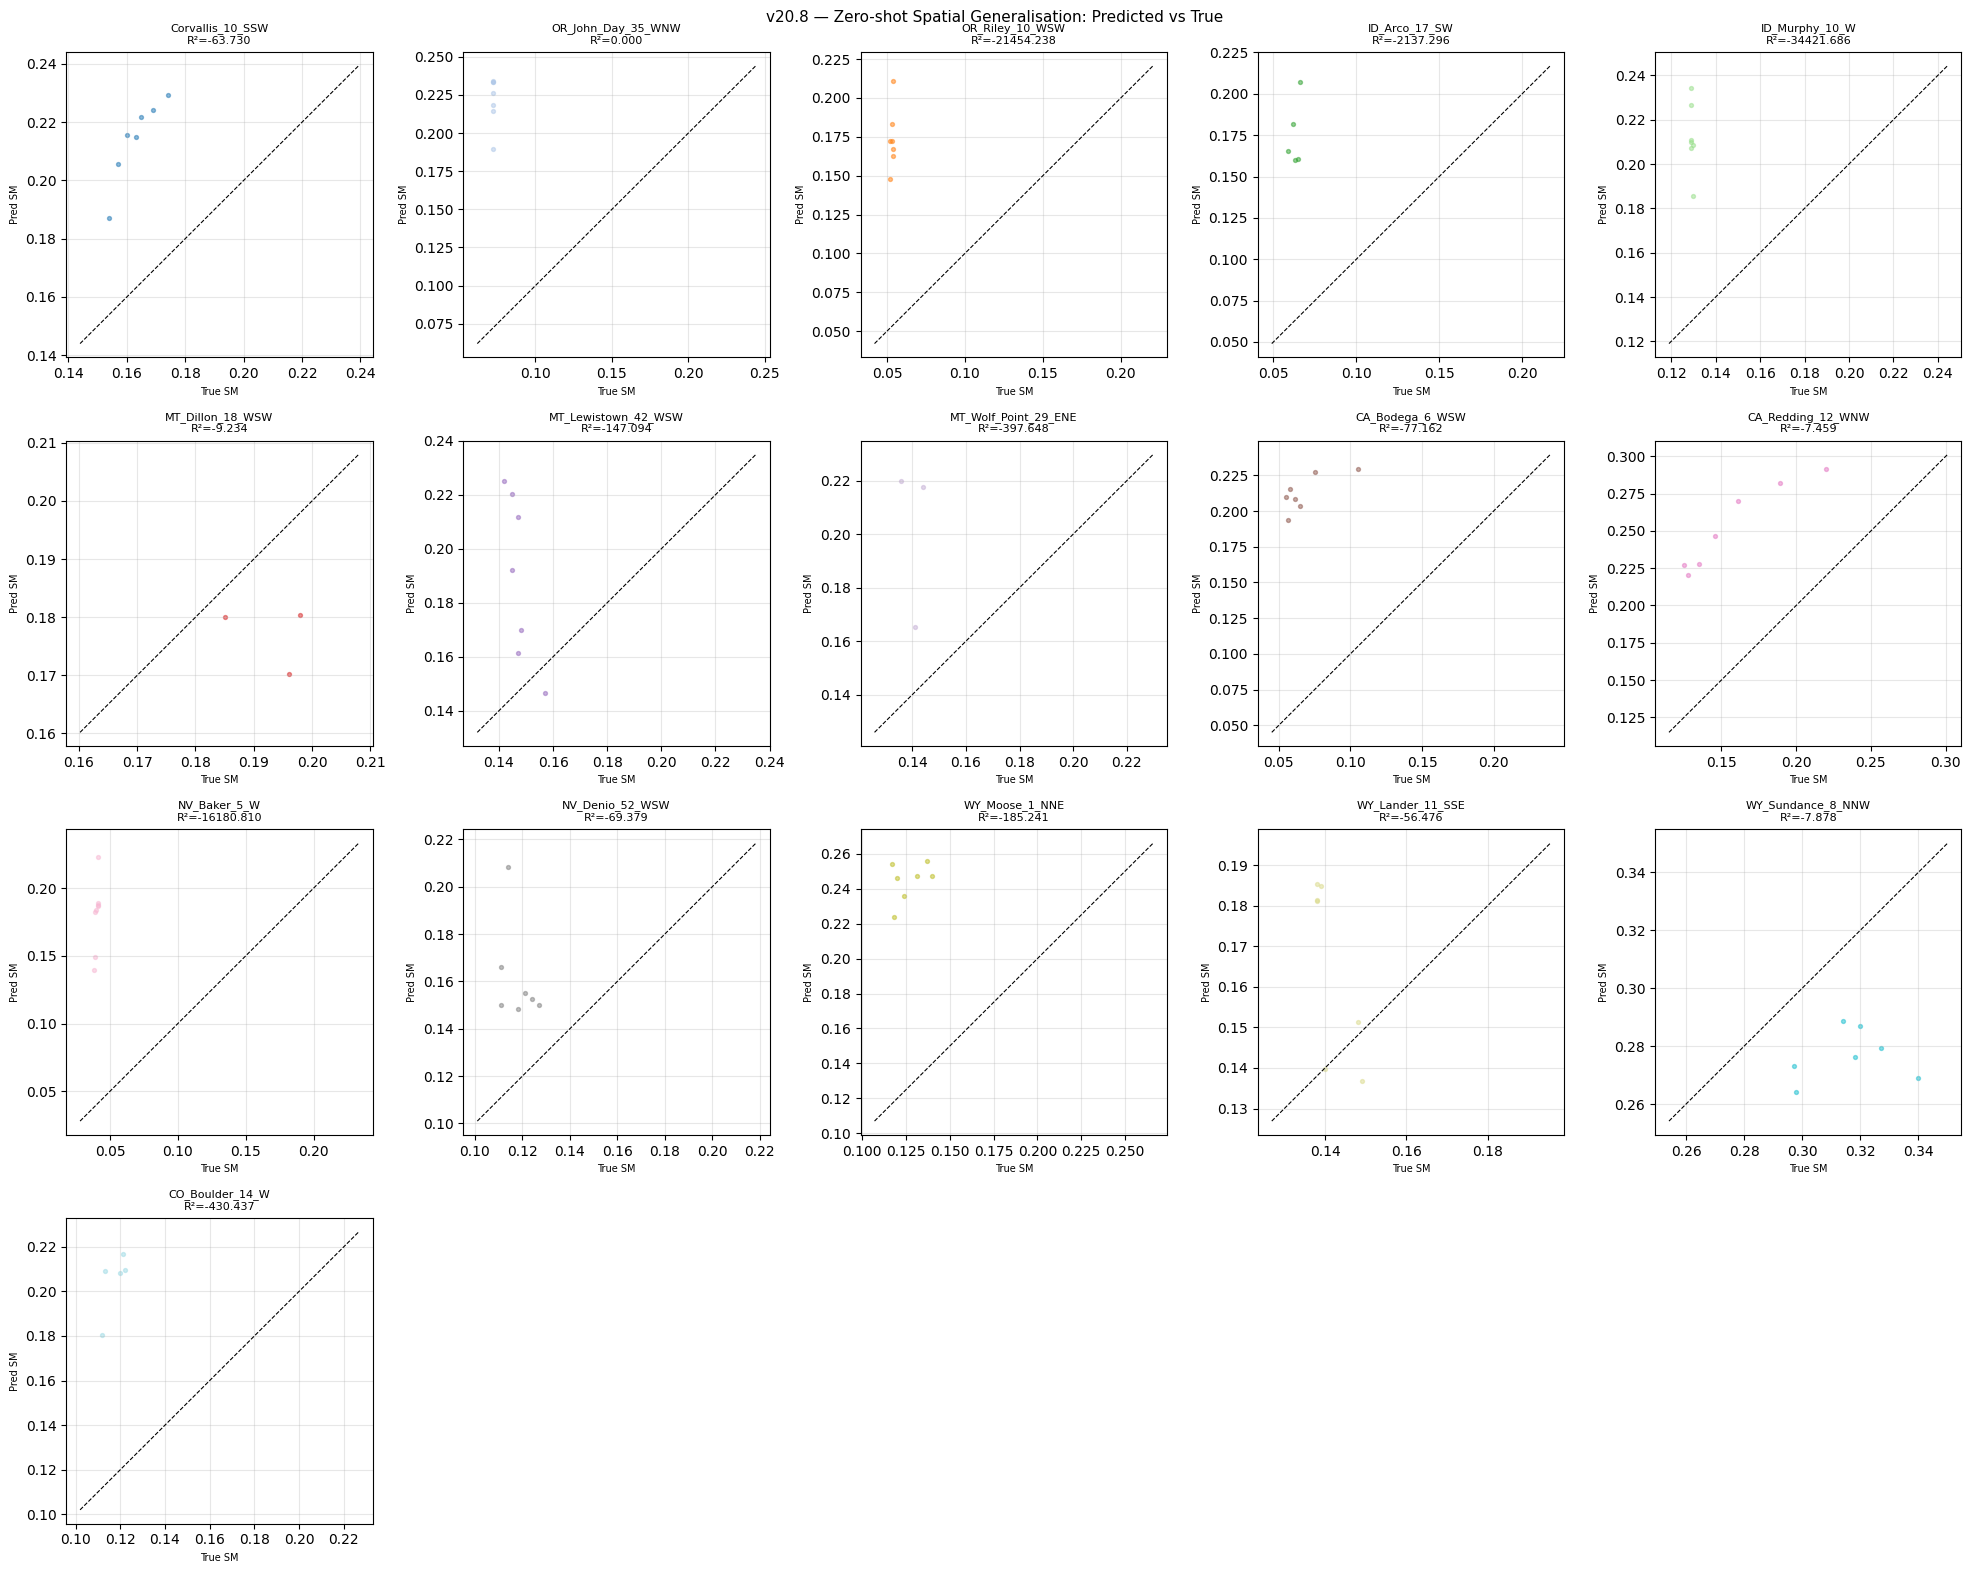

Saved → spatial_scatter.png


In [16]:
# ── Scatter: predicted vs. true ────────────────────────────────────────────────
if spatial_preds:
    n_st = len(spatial_preds)
    ncols = min(n_st, 5)
    nrows = (n_st + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes_flat  = np.array(axes).ravel()

    cmap = plt.cm.tab20
    for i, (sid, (yt, yp, dates)) in enumerate(spatial_preds.items()):
        ax = axes_flat[i]
        r2 = r2_score(yt, yp)
        ax.scatter(yt, yp, s=8, alpha=0.5, color=cmap(i / max(n_st - 1, 1)))
        lo = min(yt.min(), yp.min()) - 0.01
        hi = max(yt.max(), yp.max()) + 0.01
        ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
        ax.set_title(f'{sid}\nR²={r2:.3f}', fontsize=8)
        ax.set_xlabel('True SM', fontsize=7)
        ax.set_ylabel('Pred SM', fontsize=7)
        ax.grid(alpha=0.3)

    # hide unused axes
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.suptitle('v20.8 — Zero-shot Spatial Generalisation: Predicted vs True', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / 'spatial_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → spatial_scatter.png')

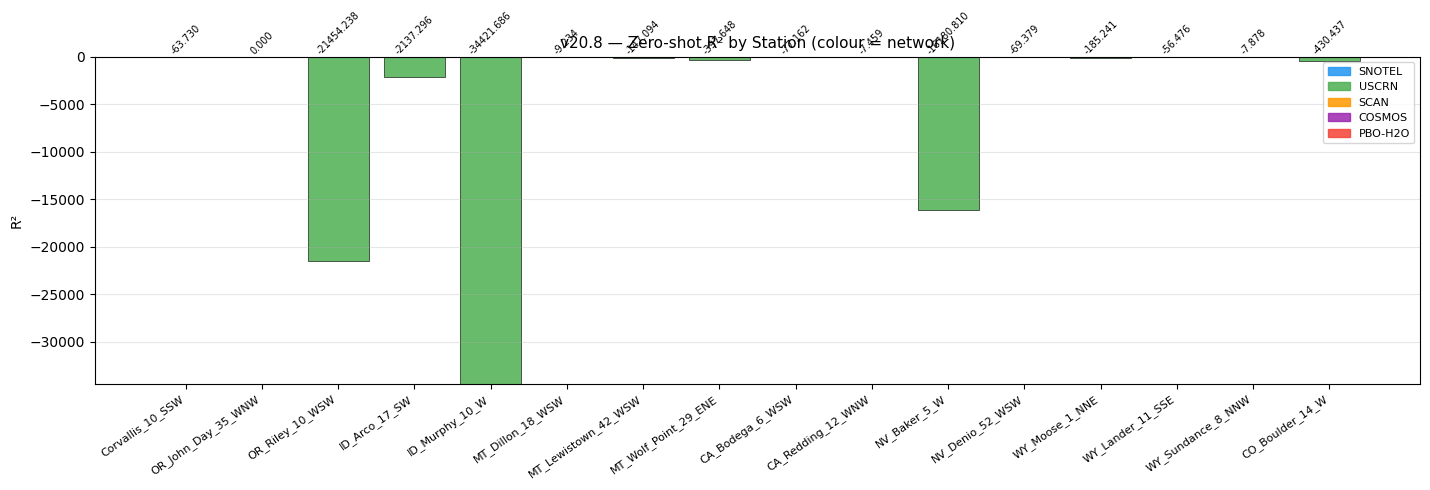

Saved → spatial_r2_bar.png


In [17]:
# ── R² bar chart grouped by network ──────────────────────────────────────────
if spatial_results:
    sdf = pd.DataFrame(spatial_results).merge(
        meta_df[['station_id', 'state', 'network']].rename(columns={'station_id': 'station'}),
        on='station', how='left'
    )

    network_colors = {'SNOTEL': '#2196F3', 'USCRN': '#4CAF50', 'SCAN': '#FF9800',
                      'COSMOS': '#9C27B0', 'PBO-H2O': '#F44336'}

    fig, ax = plt.subplots(figsize=(max(8, len(sdf) * 0.9), 5))
    x = np.arange(len(sdf))

    bars = ax.bar(x, sdf['r2'],
                  color=[network_colors.get(n, 'grey') for n in sdf['network']],
                  alpha=0.85, edgecolor='k', linewidth=0.5)

    for bar, r2, rmse in zip(bars, sdf['r2'], sdf['rmse']):
        ax.text(bar.get_x() + bar.get_width() / 2,
                max(bar.get_height(), 0) + 0.01,
                f'{r2:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

    ax.set_xticks(x)
    ax.set_xticklabels(sdf['station'], rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('R²')
    ax.set_ylim(min(-0.1, sdf['r2'].min() - 0.05), 1.05)
    ax.axhline(0, color='k', lw=0.7, linestyle='--')
    ax.set_title('v20.8 — Zero-shot R² by Station (colour = network)', fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    # legend
    handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.85)
               for c in network_colors.values()]
    ax.legend(handles, network_colors.keys(), fontsize=8, loc='upper right')

    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / 'spatial_r2_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → spatial_r2_bar.png')

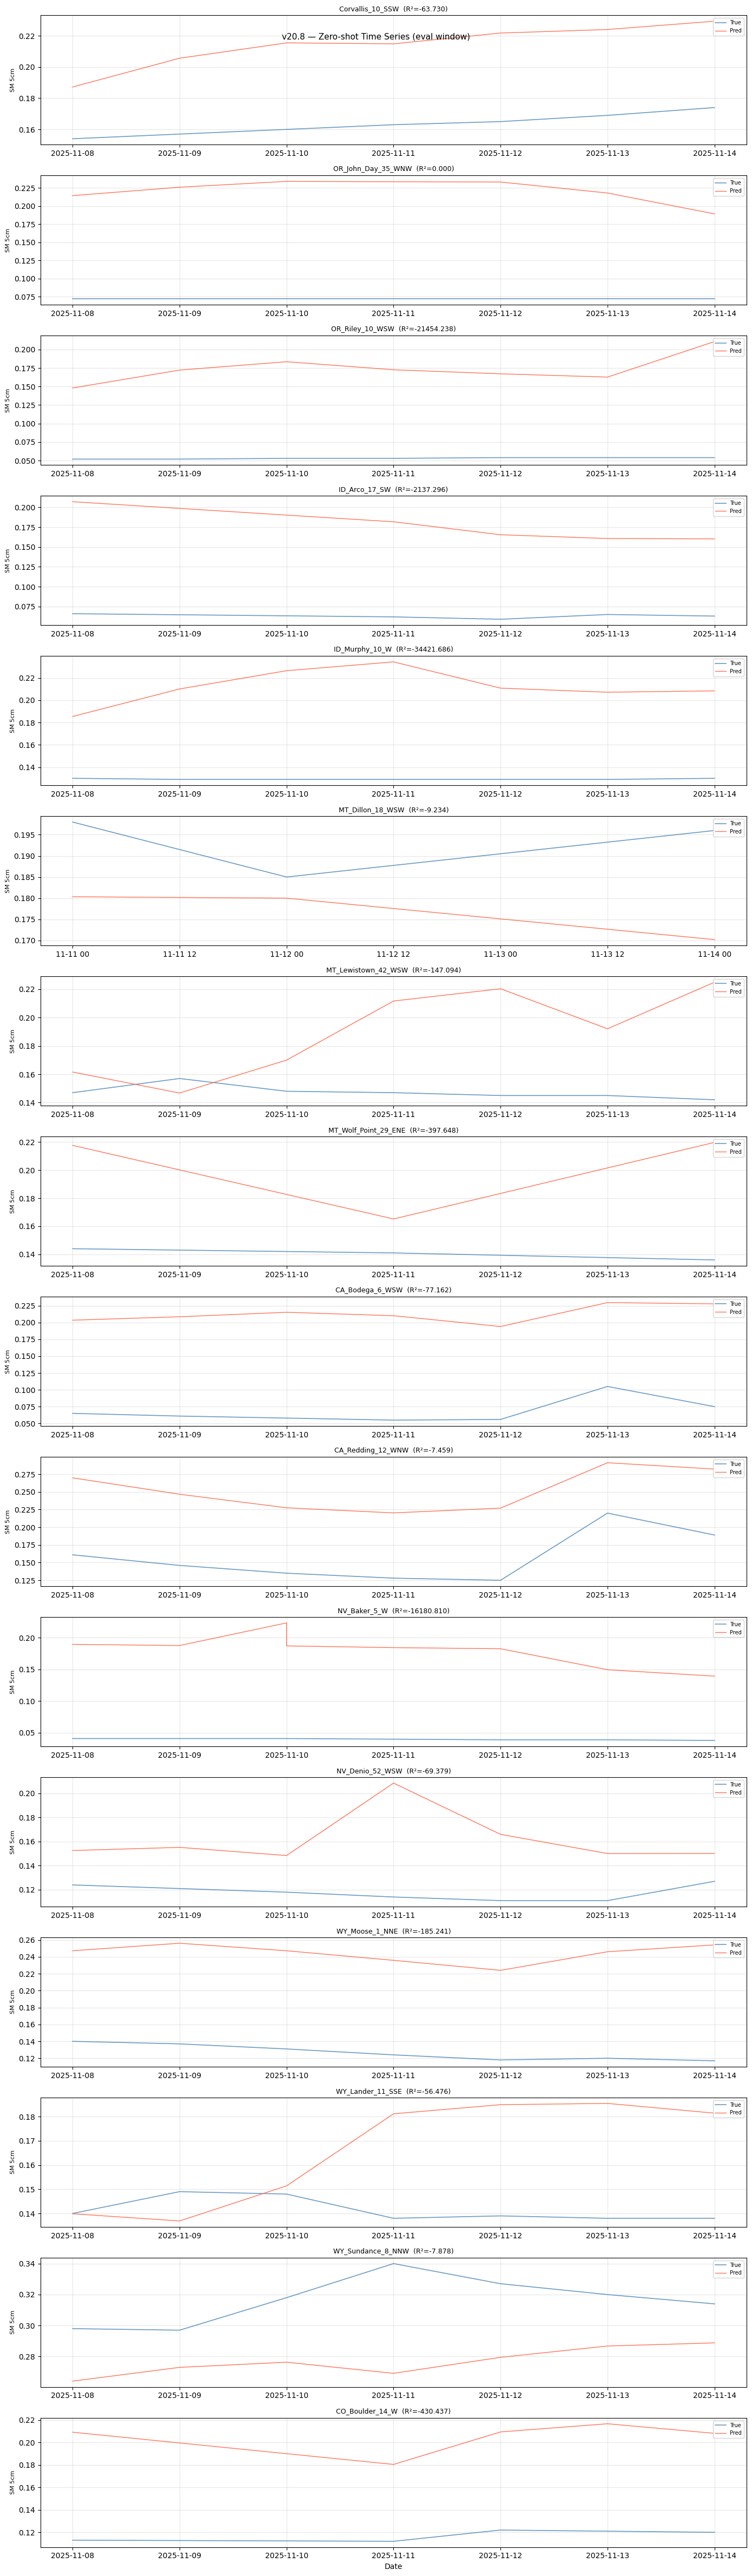

Saved → spatial_timeseries.png


In [18]:
# ── Time-series grid ──────────────────────────────────────────────────────────
if spatial_preds:
    n_st = len(spatial_preds)
    fig, axes = plt.subplots(n_st, 1, figsize=(14, 3 * n_st), sharex=False)
    if n_st == 1:
        axes = [axes]

    for ax, (sid, (yt, yp, dates)) in zip(axes, spatial_preds.items()):
        order = np.argsort(dates)
        ax.plot(dates[order], yt[order], label='True',  color='steelblue', lw=1.2, alpha=0.8)
        ax.plot(dates[order], yp[order], label='Pred',  color='tomato',    lw=1.0, alpha=0.9)
        r2 = r2_score(yt, yp)
        ax.set_title(f'{sid}  (R²={r2:.3f})', fontsize=9)
        ax.set_ylabel('SM 5cm', fontsize=8)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel('Date')
    plt.suptitle('v20.8 — Zero-shot Time Series (eval window)', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / 'spatial_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → spatial_timeseries.png')

## 15. Comparison with v20.7 LOSO baseline

Puts the zero-shot spatial results in context against the within-WA LOSO results.

In [19]:
v207_path = PROJECT_ROOT / 'Models' / 'Temporal' / 'v20' / 'v20.7' / 'loso_all_stations_summary.csv'
if v207_path.exists() and spatial_results:
    loso_df = pd.read_csv(v207_path)

    loso_mean = loso_df[['r2', 'mae', 'rmse', 'ubrmse', 'bias']].mean()
    spatial_mean = pd.DataFrame(spatial_results)[['r2', 'mae', 'rmse', 'ubrmse', 'bias']].mean()

    compare_df = pd.DataFrame({
        'Metric':         ['R²', 'MAE', 'RMSE', 'ubRMSE', 'Bias'],
        'v20.7 LOSO (WA)': [loso_mean['r2'], loso_mean['mae'], loso_mean['rmse'],
                             loso_mean['ubrmse'], loso_mean['bias']],
        'v20.8 Zero-shot (OR/ID/MT)': [spatial_mean['r2'], spatial_mean['mae'], spatial_mean['rmse'],
                                        spatial_mean['ubrmse'], spatial_mean['bias']],
    })

    display(compare_df.style.format({col: '{:.4f}' for col in compare_df.columns[1:]})
            .set_caption('v20.7 in-state LOSO vs v20.8 zero-shot spatial generalisation'))

    compare_df.to_csv(OUTPUT_ROOT / 'loso_vs_spatial_comparison.csv', index=False)
    print('Saved → loso_vs_spatial_comparison.csv')
else:
    print('v20.7 summary not found or no spatial results yet — run Sections 11-12 first')

,Metric,v20.7 LOSO (WA),v20.8 Zero-shot (OR/ID/MT)
0,R²,0.5807,-4727.8606
1,MAE,0.0498,0.0833
2,RMSE,0.0594,0.0857
3,ubRMSE,0.0549,0.0166
4,Bias,-0.0073,-0.0759


Saved → loso_vs_spatial_comparison.csv


---

## Notes

### Feature completeness
| Feature family | Source | Expected gaps |
|---|---|---|
| SMAP (daily) | GEE `SPL3SMP_E` | ~3-day latency; sparse in winter under snow |
| SAR / Sentinel-1 | GEE `COPERNICUS/S1_GRD` | ~12-day repeat cycle per pass |
| MODIS LST | GEE `MOD11A1` | Daily but cloud gaps |
| Sentinel-2 | GEE `S2_SR_HARMONIZED` | 5-day revisit; cloud-filtered |
| Precipitation | Open-Meteo historical | None |
| Static terrain+soil | GEE SRTM + OpenLandMap | None |

All satellite gaps are forward/back filled (linear interpolation, limit 10 days) before feature computation — consistent with `TemporalFillPipe` in the main pipeline.

### Interpreting results
- **R² ≥ 0.60**: Good spatial transfer — model generalises to this climate regime
- **R² 0.30–0.60**: Moderate — consider domain adaptation or fine-tuning
- **R² < 0.30**: Poor — site may fall outside the training distribution (different soil type, elevation regime, or landcover)
- **Bias > +0.05**: Model consistently under-predicts (common in drier sites not well-represented in WA training data)

### Extending to more stations
Add entries to `STATION_META` with `split='eval'` and the appropriate network. The pipeline will automatically route to the correct download function.